# cpm in five minutes

> **Level** Beginner · **Time** 5 minutes · **Prerequisites** none ·
> **cpm components** [`RLRW`](#cpm.applications.reinforcement_learning.RLRW), [`FminBound`](#cpm.optimisation.FminBound), [`Simulator`](#cpm.generators.Simulator) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data)

This page shows the whole cpm workflow in a few cells: load data, fit a ready-made model to every participant, and run the model with the fitted parameters.
Each step is explained in detail in the [tutorials](../tutorials/index.md).

**What you'll learn**

- how cpm expects data to be organised,
- how to fit a model to many participants at once,
- how to run a model with the parameters of each participant.

In [1]:
import cpm
import numpy as np
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)

0.25.7.dev0


## Load the data

cpm ships with a two-armed bandit dataset.
On each trial, participants saw two of four stimuli (`arm_left`, `arm_right`) and chose one of them (`response`: 0 for left, 1 for right).
Each stimulus paid out a reward with a different probability.

In [2]:
from cpm.datasets import load_bandit_data

data = load_bandit_data()
data.head()

,ppt,trial,arm_left,arm_right,reward_left,reward_right,response,feedback
0,1,1,2,1,0.0,1.0,1,1.0
1,1,2,3,2,1.0,0.0,0,1.0
2,1,3,1,3,1.0,0.0,0,1.0
3,1,4,1,3,0.0,0.0,0,0.0
4,1,5,2,4,1.0,0.0,0,1.0


cpm models are fitted to a column called `observed`, which holds the behaviour the model should predict.
Here that is the choice of the participant.
To keep this page fast, we use the first 20 participants.

In [3]:
data["observed"] = data["response"]
data = data[data.ppt <= 20]
print(f"{data.ppt.nunique()} participants, {len(data)} trials")

20 participants, 1439 trials


## Pick a model

[`RLRW`](#cpm.applications.reinforcement_learning.RLRW) is a Rescorla–Wagner reinforcement learning model with a softmax choice rule.
It has two free parameters: the learning rate `alpha` and the inverse temperature `temperature`.
A model in cpm is a [`Wrapper`](#cpm.generators.Wrapper): it runs the computations of one trial over all trials of one participant.
We build it with the data of a single participant; the optimiser swaps in the data of each participant when fitting.
`parameters_settings` gives the starting value, lower bound and upper bound of each parameter.

In [4]:
from cpm.applications.reinforcement_learning import RLRW

model = RLRW(
    data=data[data.ppt == 1],
    dimensions=4,
    parameters_settings=[[0.5, 0, 1], [5, 0, 10]],  # alpha, temperature
)
model.parameters.free()

['alpha', 'temperature']

## Fit it to every participant

[`FminBound`](#cpm.optimisation.FminBound) finds the parameters that maximise the likelihood of the choices of each participant, within the bounds of each parameter.
`prior=True` adds the priors of the parameters, so the estimates are maximum *a posteriori*.

In [5]:
from cpm.optimisation import FminBound, minimise

fit = FminBound(
    model=model,
    data=data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=3,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    approx_grad=True,
)
fit.optimise()

In [6]:
import pandas as pd

estimates = pd.DataFrame(fit.parameters)
estimates.describe()

,alpha,temperature
count,20.000000,20.000000
mean,0.429274,6.072600
std,0.169301,2.441618
min,0.032525,0.658943
25%,0.354631,4.917123
50%,0.452680,6.285428
75%,0.510143,7.971128
max,0.689269,9.404572


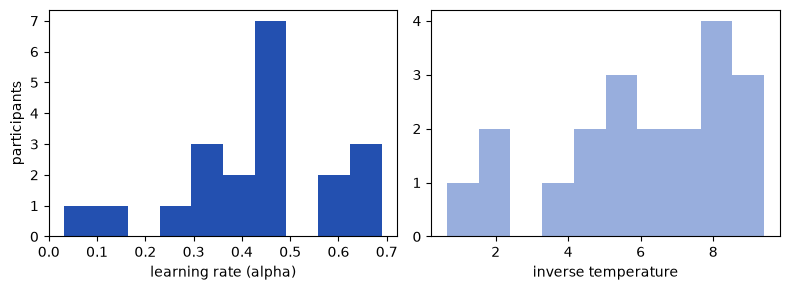

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(estimates.alpha, bins=10, color="#2350b0")
axes[0].set_xlabel("learning rate (alpha)")
axes[1].hist(estimates.temperature, bins=10, color="#98aedd")
axes[1].set_xlabel("inverse temperature")
axes[0].set_ylabel("participants")
plt.tight_layout()
plt.show()

## Run the model with the fitted parameters

The [`Simulator`](#cpm.generators.Simulator) runs the model over the trials of every participant, each with their own fitted parameters.
Its output contains everything the model returns on each trial, such as the choice probabilities (`policy_0`, `policy_1`) and the learned values of the four stimuli (`values_0` to `values_3`).

In [8]:
from cpm.generators import Simulator

simulator = Simulator(wrapper=model, parameters=estimates, data=data.groupby("ppt"))
simulator.run()
simulation = simulator.export()
simulation.head()

,policy_0,policy_1,reward,values_0,values_1,values_2,values_3,change_0,change_1,change_2,change_3,dependent,ppt
0,0.500000,0.500000,1.0,0.514486,0.250000,0.250000,0.25,0.264486,0.000000,0.000000,0.0,0.500000,1
1,0.500000,0.500000,1.0,0.514486,0.250000,0.514486,0.25,0.000000,0.000000,0.264486,0.0,0.500000,1
2,0.500000,0.500000,1.0,0.685701,0.250000,0.514486,0.25,0.171215,0.000000,0.000000,0.0,0.500000,1
3,0.829271,0.170729,0.0,0.443890,0.250000,0.514486,0.25,-0.241811,-0.000000,-0.000000,-0.0,0.170729,1
4,0.500000,0.500000,1.0,0.443890,0.514486,0.514486,0.25,0.000000,0.264486,0.000000,0.0,0.500000,1


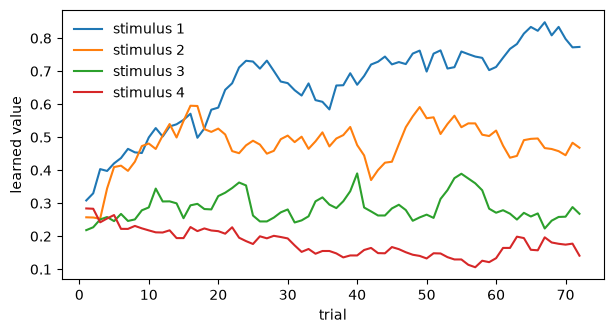

In [9]:
simulation["trial"] = simulation.groupby("ppt").cumcount() + 1
learned = simulation.groupby("trial")[["values_0", "values_1", "values_2", "values_3"]].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, column in enumerate(learned):
    ax.plot(learned.index, learned[column], label=f"stimulus {i + 1}")
ax.set_xlabel("trial")
ax.set_ylabel("learned value")
ax.legend(frameon=False)
plt.show()

## Summary and next steps

In a few lines, you fitted a reinforcement learning model to 20 participants and looked at what the model learned about each stimulus.

- To build a model of your own from cpm components, work through [Tutorial 1: Build and fit your first model](../tutorials/first-model.ipynb).
- To check whether estimates like these can be trusted, see [Tutorial 2: Parameter recovery](../tutorials/parameter-recovery.ipynb).
- To see how data, parameters and models fit together, read the [core concepts](concepts/index.md).